In [1]:
import pandas as pd
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, f1_score
from preprocessing import get_features_and_target
from visualizer import plot_visualizer, plot_visualizer_classification
import plotly.graph_objects as go
from sklearn.model_selection import StratifiedKFold
from preprocessing import get_features_and_target_classification
from tabpfn import TabPFNClassifier, TabPFNRegressor
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
import xgboost as xgb
from xgboost import XGBRegressor

In [2]:
import huggingface_hub
huggingface_hub.login()

# Getting Dataframe

In [3]:
# Load the training and development datasets
train_df = pd.read_csv("data/train_data.csv")
dev_df = pd.read_csv("data/development_data.csv")
#sc = StandardScaler()

target_column_class = "Category" 


x_train, y_train  = get_features_and_target(train_df, target_column_class)
x_dev, y_dev = get_features_and_target(dev_df, target_column_class)

#x_train = sc.fit_transform(X=x_train)
#x_dev = sc.transform(x_dev)

# Defining Model

In [4]:
#model = 'XGBoost'
model = 'TabPFNClassifier'

In [5]:
x_train

,Pressure (PSI),Welding Time (ms),Angle (Deg),Force (N),Current (A),Thickness A (mm),Thickness B (mm)
0,35,200,0,6.82,1081.47,0.922,0.920
1,35,1500,0,52.25,2014.73,0.920,0.925
2,95,200,0,16.57,1321.93,0.912,0.924
3,95,200,0,41.42,1615.83,0.948,0.939
4,35,1500,0,63.82,1137.29,0.930,0.937
...,...,...,...,...,...,...,...
290,60,1200,0,98.51,4429.61,0.625,0.622
291,60,1200,0,97.32,2636.69,0.622,0.632
292,60,1200,0,98.07,3601.67,0.666,0.633
293,60,1200,0,97.09,4161.74,0.615,0.619


# Add Physical Columns Interfacial_Failure and Pullout_Failure

In [6]:
def compute_interfacial_failure(df):
     t = df[['Thickness A (mm)', 'Thickness B (mm)']].min(axis=1) 
     f_pull = 1 * (np.pi/4) * (4 * np.sqrt(t))**2 * (0.7 * 365) 
     return np.round(f_pull, 1) 

def compute_pullout_failure(df):
     t = df[['Thickness A (mm)', 'Thickness B (mm)']].min(axis=1) 
     x = df[['Thickness A (mm)', 'Thickness B (mm)']].sum(axis=1)
     # x can be approximated to metal sheet thickness. Change 2*t either to t to use the thinner 
     # metal sheet or 2*x to test if the sum of both metal sheets give beter results
     f_pull = np.pi * ((4 * np.sqrt(t)) + 2*t)*t*365 
     return np.round(f_pull, 1) 

In [7]:
x_dev

,Pressure (PSI),Welding Time (ms),Angle (Deg),Force (N),Current (A),Thickness A (mm),Thickness B (mm)
0,95,1500,0,124.19,1045.90,0.918,0.925
1,35,200,0,6.58,1171.55,0.931,0.922
2,95,1500,0,124.16,1078.29,0.925,0.930
3,35,200,0,6.61,916.16,0.936,0.927
4,35,1500,15,54.11,1440.24,0.930,0.946
...,...,...,...,...,...,...,...
94,60,1200,0,97.26,3624.99,0.624,0.627
95,60,1200,0,97.29,4311.15,0.623,0.630
96,60,1200,0,98.26,3490.11,0.627,0.626
97,60,1200,0,98.15,3311.58,0.619,0.624


# Fit Model

In [8]:
# Target value

classifier = TabPFNClassifier() 

classifier.fit(x_train,y_train)

predictions_class_train = classifier.predict(x_train)
predictions_class_dev = classifier.predict(x_dev)



# Add Pullforce as Target

In [9]:
def compute_pullforces(x, y, predictions_class):
    pullforces = []

    for sample_id, pred in zip(y.index, predictions_class):
        row_x_df = x.loc[[sample_id]]  # 1-row DataFrame

        if pred == "Bad":
            value = compute_interfacial_failure(row_x_df).iloc[0]
        else:
            value = compute_pullout_failure(row_x_df).iloc[0]

        pullforces.append(value)

    return np.array(pullforces)


In [10]:
predictions_class_train = classifier.predict(x_train)
pullforces_train = compute_pullforces(x_train, y_train, predictions_class_train)


predictions_class_dev = classifier.predict(x_dev)
pullforces_dev = compute_pullforces(x_dev, y_dev, predictions_class_dev)


In [11]:
print(predictions_class_dev)

['Good' 'Bad' 'Good' 'Bad' 'Good' 'Bad' 'Good' 'Bad' 'Good' 'Good' 'Good'
 'Good' 'Good' 'Good' 'Good' 'Good' 'Good' 'Good' 'Good' 'Good' 'Good'
 'Good' 'Good' 'Good' 'Good' 'Good' 'Good' 'Good' 'Good' 'Good' 'Good'
 'Good' 'Good' 'Good' 'Good' 'Good' 'Good' 'Good' 'Good' 'Good' 'Good'
 'Good' 'Good' 'Good' 'Good' 'Good' 'Good' 'Good' 'Good' 'Good' 'Good'
 'Good' 'Good' 'Good' 'Good' 'Good' 'Good' 'Good' 'Good' 'Good' 'Good'
 'Good' 'Good' 'Good' 'Good' 'Good' 'Good' 'Good' 'Good' 'Good' 'Good'
 'Good' 'Good' 'Good' 'Good' 'Good' 'Good' 'Good' 'Good' 'Good' 'Good'
 'Good' 'Good' 'Good' 'Good' 'Good' 'Good' 'Good' 'Good' 'Good' 'Good'
 'Good' 'Good' 'Good' 'Good' 'Good' 'Good' 'Good' 'Good']


In [12]:
print(pullforces_dev)

[5967.  2960.3 6042.8 2976.3 6097.2 2976.3 6097.2 3018.1 3423.9 3170.5
 3245.7 3237.3 3254.1 3304.7 3195.5 3245.7 3153.9 3203.8 3087.8 3330.1
 3245.7 3270.9 3162.2 3187.1 3220.5 3220.5 3145.6 3187.1 3129.  3162.2
 3096.  3112.5 3220.5 3228.9 3096.  3254.1 3270.9 3137.3 3170.5 3212.2
 3137.3 3254.1 3228.9 3145.6 3212.2 3220.5 3254.1 3262.5 3145.6 3071.3
 3055.  3038.6 3178.8 3129.  3162.2 3145.6 3170.5 3120.8 3162.2 3178.8
 3153.9 3104.3 3137.3 3153.9 3129.  3137.3 3096.  3055.  3079.6 3137.3
 3104.3 3220.5 3162.2 3178.8 3112.5 3104.3 3137.3 3104.3 3129.  3187.1
 3212.2 3145.6 3195.5 3170.5 3170.5 3112.5 3120.8 3162.2 3153.9 3170.5
 3038.6 3112.5 3153.9 3071.3 3153.9 3145.6 3170.5 3112.5 3153.9]


In [13]:
y_train_Regressor = train_df.groupby("Sample ID")['PullTest (N)'].first()
y_train_delta =  pullforces_train - y_train_Regressor

y_dev_Regressor = dev_df.groupby("Sample ID")['PullTest (N)'].first()
y_dev_delta = pullforces_dev - y_dev_Regressor


In [14]:
y_train_Regressor.head(10)

Sample ID
1     2127.7
2     5346.4
4     2350.4
5     2174.8
7     3897.5
9     1932.5
11    3816.0
12    1832.5
15    5634.8
17    2685.9
Name: PullTest (N), dtype: float64

In [15]:
pullforces_train

array([2953.9, 5988.6, 2928.2, 3014.9, 6097.2, 2979.5, 6064.5, 2937.8,
       6108.1, 3005.2, 2969.9, 2969.9, 2979.5, 6162.7, 6283.7, 6305.8,
       2966.7, 3195.5, 3270.9, 3279.3, 3178.8, 3321.6, 3237.3, 3153.9,
       3120.8, 3203.8, 3178.8, 3195.5, 3287.8, 3228.9, 3270.9, 3245.7,
       3212.2, 3212.2, 3212.2, 3212.2, 3120.8, 3279.3, 3096. , 3137.3,
       3087.8, 3153.9, 3220.5, 3287.8, 3178.8, 3203.8, 3262.5, 3162.2,
       3187.1, 3145.6, 3220.5, 3145.6, 3237.3, 3162.2, 3220.5, 3245.7,
       3170.5, 3203.8, 3262.5, 3270.9, 3254.1, 3220.5, 3237.3, 3237.3,
       3237.3, 3220.5, 3338.6, 3228.9, 3304.7, 3245.7, 3178.8, 3145.6,
       3145.6, 3262.5, 3162.2, 3162.2, 3228.9, 3195.5, 3137.3, 3237.3,
       3254.1, 3245.7, 3120.8, 3087.8, 3112.5, 3104.3, 3071.3, 3104.3,
       3120.8, 3087.8, 3055. , 3087.8, 3079.6, 3245.7, 3195.5, 3162.2,
       3304.7, 3145.6, 3079.6, 3104.3, 3212.2, 3245.7, 3262.5, 3262.5,
       3212.2, 3237.3, 3195.5, 3237.3, 3220.5, 3212.2, 3212.2, 3162.2,
      

In [16]:
y_train_delta.head(10)

Sample ID
1      826.2
2      642.2
4      577.8
5      840.1
7     2199.7
9     1047.0
11    2248.5
12    1105.3
15     473.3
17     319.3
Name: PullTest (N), dtype: float64

In [17]:
x_train

,Pressure (PSI),Welding Time (ms),Angle (Deg),Force (N),Current (A),Thickness A (mm),Thickness B (mm)
0,35,200,0,6.82,1081.47,0.922,0.920
1,35,1500,0,52.25,2014.73,0.920,0.925
2,95,200,0,16.57,1321.93,0.912,0.924
3,95,200,0,41.42,1615.83,0.948,0.939
4,35,1500,0,63.82,1137.29,0.930,0.937
...,...,...,...,...,...,...,...
290,60,1200,0,98.51,4429.61,0.625,0.622
291,60,1200,0,97.32,2636.69,0.622,0.632
292,60,1200,0,98.07,3601.67,0.666,0.633
293,60,1200,0,97.09,4161.74,0.615,0.619


# Fit 2nd Model

In [18]:
# Initialize the regressor
regressor = TabPFNRegressor()  # Uses TabPFN-2.5 weights, trained on synthetic data only.
# To use TabPFN v2:
# regressor = TabPFNRegressor.create_default_for_version(ModelVersion.V2)


regressor.fit(x_train, y_train_delta)

# Predict on the test set
predictions_class_dev = regressor.predict(x_dev)
    

final_pred = pullforces_dev + predictions_class_dev

pred_series = pd.Series(predictions_class_dev, index=x_dev.index)
pull_series = pd.Series(pullforces_dev, index=y_dev.index)

final_pred = pull_series.loc[pred_series.index] - pred_series


In [19]:
pred_series

0     1807.190063
1      829.858643
2     1795.273682
3      845.204590
4      881.713562
         ...     
94     203.049149
95     206.984940
96     203.376511
97     198.399994
98     257.196747
Length: 99, dtype: float32

In [20]:
pull_series

0     5967.0
1     2960.3
2     6042.8
3     2976.3
4     6097.2
       ...  
94    3153.9
95    3145.6
96    3170.5
97    3112.5
98    3153.9
Length: 99, dtype: float64

In [21]:
pullforces_dev

array([5967. , 2960.3, 6042.8, 2976.3, 6097.2, 2976.3, 6097.2, 3018.1,
       3423.9, 3170.5, 3245.7, 3237.3, 3254.1, 3304.7, 3195.5, 3245.7,
       3153.9, 3203.8, 3087.8, 3330.1, 3245.7, 3270.9, 3162.2, 3187.1,
       3220.5, 3220.5, 3145.6, 3187.1, 3129. , 3162.2, 3096. , 3112.5,
       3220.5, 3228.9, 3096. , 3254.1, 3270.9, 3137.3, 3170.5, 3212.2,
       3137.3, 3254.1, 3228.9, 3145.6, 3212.2, 3220.5, 3254.1, 3262.5,
       3145.6, 3071.3, 3055. , 3038.6, 3178.8, 3129. , 3162.2, 3145.6,
       3170.5, 3120.8, 3162.2, 3178.8, 3153.9, 3104.3, 3137.3, 3153.9,
       3129. , 3137.3, 3096. , 3055. , 3079.6, 3137.3, 3104.3, 3220.5,
       3162.2, 3178.8, 3112.5, 3104.3, 3137.3, 3104.3, 3129. , 3187.1,
       3212.2, 3145.6, 3195.5, 3170.5, 3170.5, 3112.5, 3120.8, 3162.2,
       3153.9, 3170.5, 3038.6, 3112.5, 3153.9, 3071.3, 3153.9, 3145.6,
       3170.5, 3112.5, 3153.9])

In [22]:
final_pred

0     4159.809937
1     2130.441357
2     4247.526318
3     2131.095410
4     5215.486438
         ...     
94    2950.850851
95    2938.615060
96    2967.123489
97    2914.100006
98    2896.703253
Length: 99, dtype: float64

In [23]:
y_dev

0        Good
1         Bad
2        Good
3         Bad
4     Explode
       ...   
94       Good
95       Good
96       Good
97       Good
98    Explode
Name: Category, Length: 99, dtype: object

# Check Validation Data

In [24]:
# Category array (must be aligned with y_dev)
categories = dev_df.groupby("Sample ID")["Category"].first().values

plot_visualizer(
    true_vals=y_dev_Regressor,
    pred_vals=final_pred,
    categories=categories,
    title=f"Validation Samples: True vs Prediction (TabPFN) by Category"
)

# Check Validation Loss and R2

In [25]:
# Calculate MAE and RMSE and R2
mae  = mean_absolute_error(y_dev_Regressor, final_pred)
rmse = np.sqrt(mean_squared_error(y_dev_Regressor, final_pred))
R2   = r2_score(y_dev_Regressor, final_pred)


print(f"MAE:  {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R2: {R2:.2f}")

MAE:  131.54
RMSE: 225.02
R2: 0.60


# Cross Validation

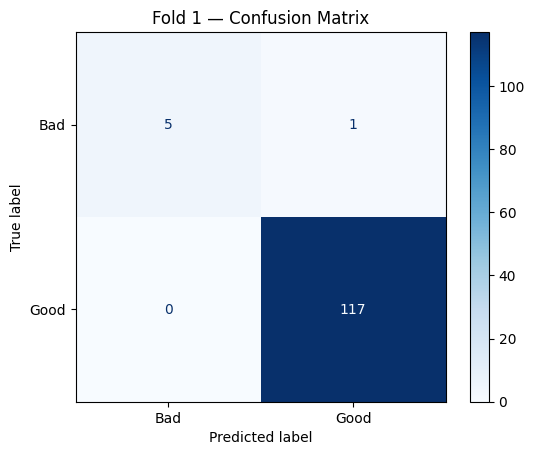

F1 Score: 0.622702434177844


Pearson correlation (Physics vs True PullForce): 0.7626


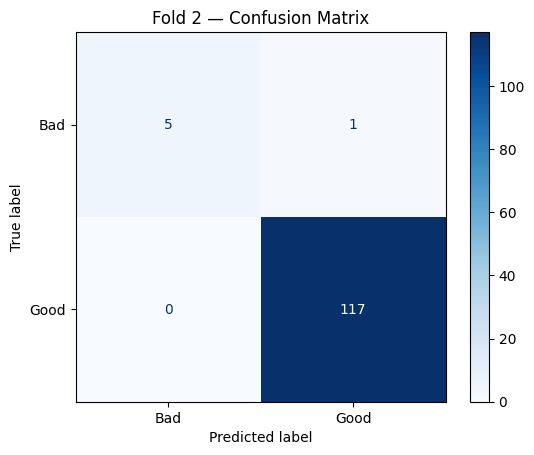

F1 Score: 0.6240179573512906


Pearson correlation (Physics vs True PullForce): 0.6996


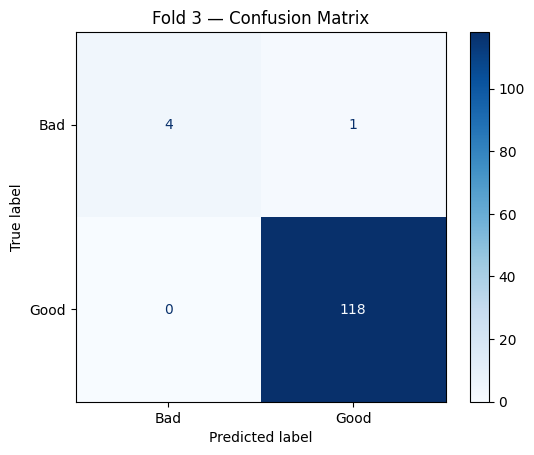

F1 Score: 0.6173847316704459


Pearson correlation (Physics vs True PullForce): 0.7447

=== FINAL CROSS‑VALIDATION RESULTS ===

--- Direct Model ---
MAE mean: 131.88
RMSE mean: 229.08
R² mean: 0.68


In [ ]:
cross_df = pd.read_csv("data/train_dev_data.csv")
target_column_regression = "PullTest (N)" 

skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

direct_mae, direct_rmse, direct_r2 = [], [], [] 
hybrid_mae, hybrid_rmse, hybrid_r2 = [], [], [] 

for fold, (train_index, val_index) in enumerate(skf.split(cross_df["Sample ID"], cross_df["Category"])):

    # -----------------------------
    # 1. Build fold-specific data
    # -----------------------------
    train_df = cross_df.iloc[train_index].copy()
    val_df   = cross_df.iloc[val_index].copy()

    # Group targets by Sample ID (SAME as non‑CV pipeline)
    y_train_reg = train_df.groupby("Sample ID")["PullTest (N)"].first()
    y_val_reg   = val_df.groupby("Sample ID")["PullTest (N)"].first()

    # Build feature matrices at Sample ID level
    x_train = train_df.groupby("Sample ID").first()
    x_val   = val_df.groupby("Sample ID").first()

    x_tr_class, y_tr_class = get_features_and_target(x_train, target_column_class)
    x_val_class, y_val_class = get_features_and_target(x_val, target_column_class)

    x_tr_reg, y_tr_reg = get_features_and_target(x_train, target_column_regression)
    x_val_reg, y_val_reg = get_features_and_target(x_val, target_column_regression)

    #Classification
    classifier = TabPFNClassifier()
    classifier.fit(x_tr_class,y_tr_class)

    predictions_class_train = classifier.predict(x_tr_class)
    predictions_class_dev = classifier.predict(x_val_class)

    # Plot classification results for this fold
    plot_visualizer_classification(
        y_true=y_val_class,
        y_pred=predictions_class_dev,
        class_labels=["Bad", "Good"],
        title=f"Fold {fold+1} — Confusion Matrix"
    )


    physics_train = compute_pullforces(x_tr_reg, y_tr_reg, predictions_class_train) 
    physics_val = compute_pullforces(x_val_reg, y_val_reg, predictions_class_dev)

    y_train_delta = physics_train - y_train_reg 

    regressor = TabPFNRegressor()
    regressor.fit(x_tr_reg, y_train_delta)

    prediciton = regressor.predict(x_val_reg)
    final_pred_regression_dev_without_physics  = physics_val - prediciton

    direct_mae.append(mean_absolute_error(y_val_reg, final_pred_regression_dev_without_physics)) 
    direct_rmse.append(np.sqrt(mean_squared_error(y_val_reg, final_pred_regression_dev_without_physics))) 
    direct_r2.append(r2_score(y_val_reg, final_pred_regression_dev_without_physics))

    # Categories
    categories= cross_df.iloc[val_index]["Category"].values

    plot_visualizer(
        true_vals=y_val_reg,
        pred_vals=final_pred_regression_dev_without_physics,
        categories=categories,
        title=f"Fold {fold+1}: True vs Prediction (TabPFN) by Category"
    )

    corr = np.corrcoef(physics_train, y_train_reg)[0,1] 
    print(f"Pearson correlation (Physics vs True PullForce): {corr:.4f}")
    print(f"Direct:\n MAE={direct_mae[-1]:.2f},\n RMSE={direct_rmse[-1]:.2f},\n R²={direct_r2[-1]:.2f}\n")

print("\n=== FINAL CROSS‑VALIDATION RESULTS ===") 
print("\n--- Direct Model ---") 
print(f"MAE mean: {np.mean(direct_mae):.2f}") 
print(f"RMSE mean: {np.mean(direct_rmse):.2f}") 
print(f"R² mean: {np.mean(direct_r2):.2f}")